# 6CS012 – Final Portfolio: Vision Task
## ASL Alphabet Recognition with CNNs and Transfer Learning
**Parts A & B** | Herald College, Kathmandu | April 2026

---
> Add both datasets as Kaggle inputs:
> - `grassknoted/asl-alphabet` (training)
> - `danrasband/asl-alphabet-test` (test)
>
> On **Google Colab**, use the Kaggle API section below to download.

---
## 0. Environment Setup

In [ ]:
import os

# Use riftuser home directory instead of /root
kaggle_dir = '/home/riftuser/.config/kaggle'
os.makedirs(kaggle_dir, exist_ok=True)

!cp /home/riftuser/kaggle.json /home/riftuser/.config/kaggle/kaggle.json
!chmod 600 /home/riftuser/.config/kaggle/kaggle.json

# Verify kaggle works
!kaggle --version

cp: cannot stat '/home/riftuser/kaggle.json': No such file or directory
chmod: cannot access '/home/riftuser/.config/kaggle/kaggle.json': No such file or directory
Kaggle CLI 2.1.0


In [ ]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
import random

import sklearn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import ResNet50

warnings.filterwarnings('ignore')
print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1777299766.395255   12177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777299766.485993   12177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.21.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1777299767.926908   12177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
COLAB_TRAIN = Path('data/asl_alphabet_train/asl_alphabet_train')
COLAB_TEST  = Path('data/asl-alphabet-test')


TRAIN_DIR = COLAB_TRAIN
TEST_DIR  = COLAB_TEST

# Quick sanity check
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("Classes sample:", sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])[:5])

print(f'Train dir: {TRAIN_DIR}')
print(f'Test dir : {TEST_DIR}')



TRAIN_DIR exists: True
Classes sample: ['A', 'B', 'C', 'D', 'E']
Train dir: data/asl_alphabet_train/asl_alphabet_train
Test dir : data/asl-alphabet-test


In [ ]:
# ── Global hyperparameters ────────────────────────────────────────────────────
IMG_SIZE_A  = 64          # Part A scratch CNNs  (fast, memory-friendly)
IMG_SIZE_B  = 224         # Part B transfer learning (ImageNet standard)
BATCH_SIZE  = 64
NUM_CLASSES = 27          # A-Z + Nothing
SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

VALID_CLASSES = sorted([chr(i) for i in range(ord('A'), ord('Z')+1)] + ['nothing'])
print(f"Using {len(VALID_CLASSES)} classes: {VALID_CLASSES}")

Using 27 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing']


---
## PART A – CNNs from Scratch
### Section 2.5.1 – Data Understanding, Analysis, Visualisation & Cleaning
---

#### 1.1 Dataset Description

The **ASL Alphabet dataset** (Kaggle – grassknoted) contains colour photographs of hand gestures representing the 26 letters of the American Sign Language (ASL) alphabet plus a "Nothing" class (blank/background).  
Each image is **200 × 200 px RGB**, captured under varied lighting conditions and skin tones, making it a realistic benchmark for gesture-recognition systems.  
A separate held-out **test set** (danrasband) is used for final evaluation.

In [ ]:
# ── 1.2  Count images and classes ─────────────────────────────────────────────
def get_images(cls_dir):
    """Grab image paths regardless of extension case."""
    paths = []
    for ext in ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']:
        paths.extend(cls_dir.glob(ext))
    return paths

class_names = VALID_CLASSES

class_counts = {}
for cls in class_names:
    cls_dir = TRAIN_DIR / cls
    imgs = get_images(cls_dir)
    class_counts[cls] = len(imgs)

total_images = sum(class_counts.values())
print(f'Total training images : {total_images:,}')
print(f'Images per class (sample) :')
for cls, cnt in list(class_counts.items())[:5]:
    print(f'  {cls}: {cnt}')

Total training images : 81,000
Images per class (sample) :
  A: 3000
  B: 3000
  C: 3000
  D: 3000
  E: 3000


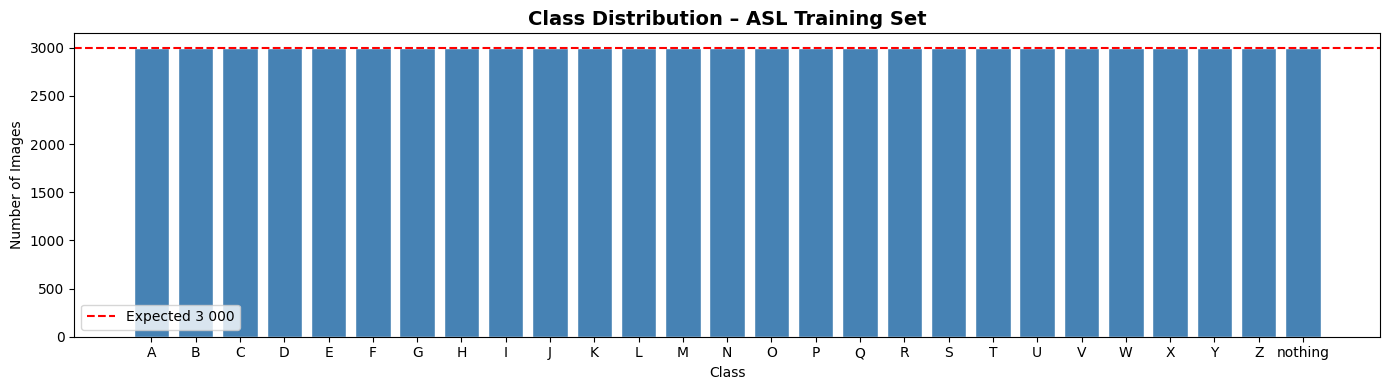


Observation: The dataset is perfectly balanced — 3 000 images per class.
No oversampling or class-weight balancing is required.


In [ ]:
# ── 1.3  Class distribution bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='white')
ax.set_title('Class Distribution – ASL Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.axhline(3000, color='red', linestyle='--', label='Expected 3 000')
ax.legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('\nObservation: The dataset is perfectly balanced — 3 000 images per class.\n'
      'No oversampling or class-weight balancing is required.')

In [ ]:
# ── 1.4  Sample image grid ────────────────────────────────────────────────────

# Debug: check what extensions actually exist
sample_cls = class_names[0]
all_files = list((TRAIN_DIR / sample_cls).iterdir())
print(f"Files in '{sample_cls}': {[f.name for f in all_files[:5]]}")
print(f"Extensions found: {set(f.suffix for f in all_files)}")

Files in 'A': ['A781.jpg', 'A1670.jpg', 'A1338.jpg', 'A2120.jpg', 'A1901.jpg']
Extensions found: {'.jpg'}


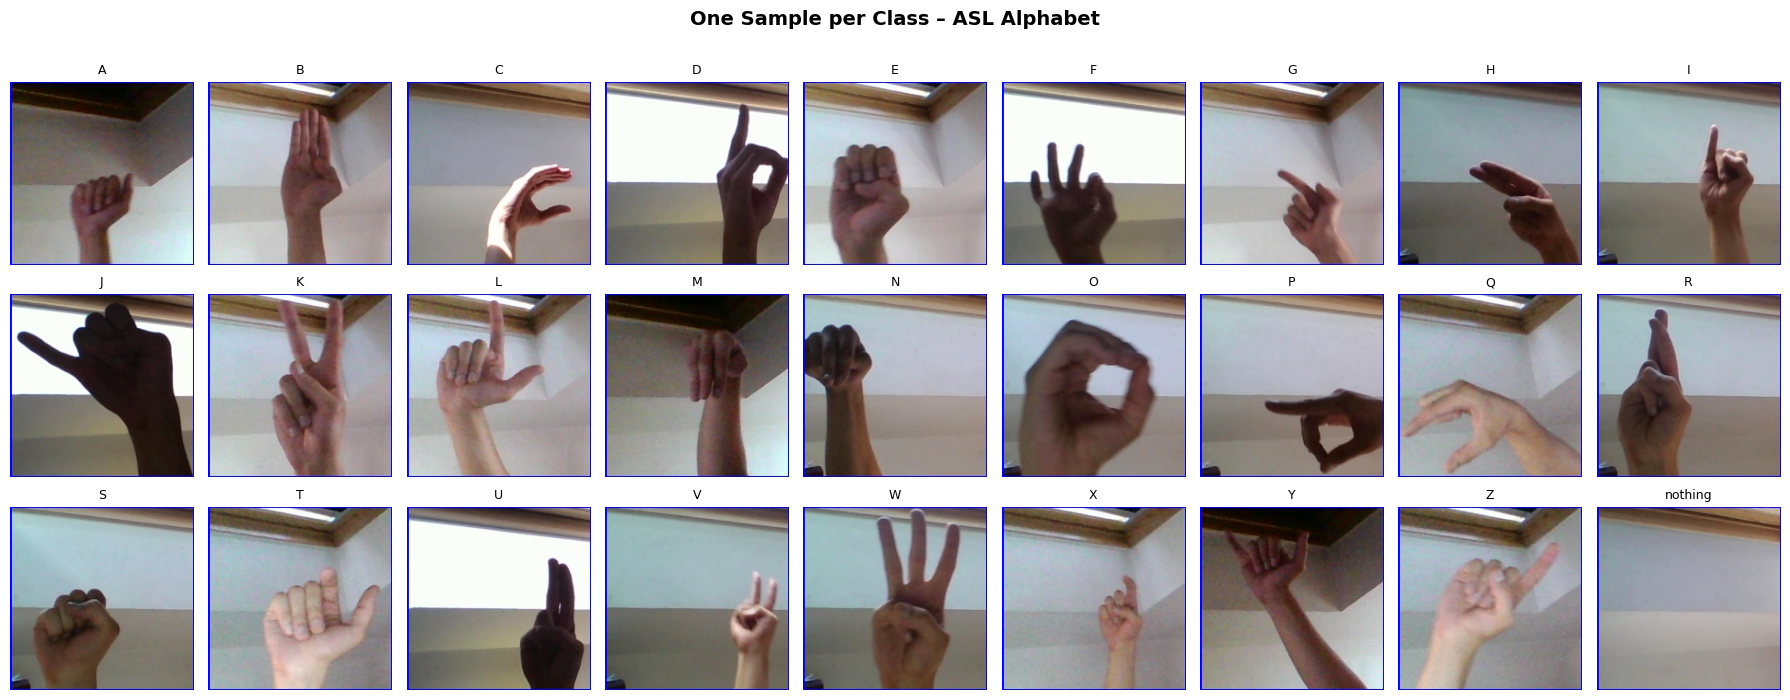

In [ ]:
def get_images(cls_dir, n=1):
    """Grab image paths regardless of extension case."""
    paths = []
    for ext in ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']:
        paths.extend(cls_dir.glob(ext))
    return paths

fig, axes = plt.subplots(3, 9, figsize=(18, 7))
for ax, cls in zip(axes.flatten(), class_names):
    cls_dir = TRAIN_DIR / cls
    imgs = get_images(cls_dir)
    if not imgs:
        print(f"WARNING: No images found in {cls_dir}")
        ax.axis('off')
        continue
    img_path = random.choice(imgs)
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(cls, fontsize=9)
    ax.axis('off')

plt.suptitle('One Sample per Class – ASL Alphabet', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 1.5  Train / Validation split & data generators ──────────────────────────
# We use an 80/20 split.  ImageDataGenerator handles the split automatically
# via validation_split.  No manual file copying needed.
#
# Justification for 80/20:
#  • 81 000 images → 64 800 train / 16 200 validation
#  • Each class retains ~540 validation examples — sufficient for stable metrics.
#  • Larger training set preferred because the dataset is already well-balanced.

# Augmentation only on training generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=False,   # ASL signs are NOT mirror-symmetric
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    classes=VALID_CLASSES,          # ← only A-Z + nothing, ignores del and space
    target_size=(IMG_SIZE_A, IMG_SIZE_A),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    classes=VALID_CLASSES,          # ← same filter
    target_size=(IMG_SIZE_A, IMG_SIZE_A),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print(f"NUM_CLASSES confirmed : {NUM_CLASSES}")
print(f'Training samples      : {train_gen.samples:,}')
print(f'Validation samples    : {val_gen.samples:,}')
print(f'Classes               : {list(train_gen.class_indices.keys())}')

Found 64800 images belonging to 27 classes.
Found 16200 images belonging to 27 classes.
NUM_CLASSES confirmed : 27
Training samples      : 64,800
Validation samples    : 16,200
Classes               : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing']


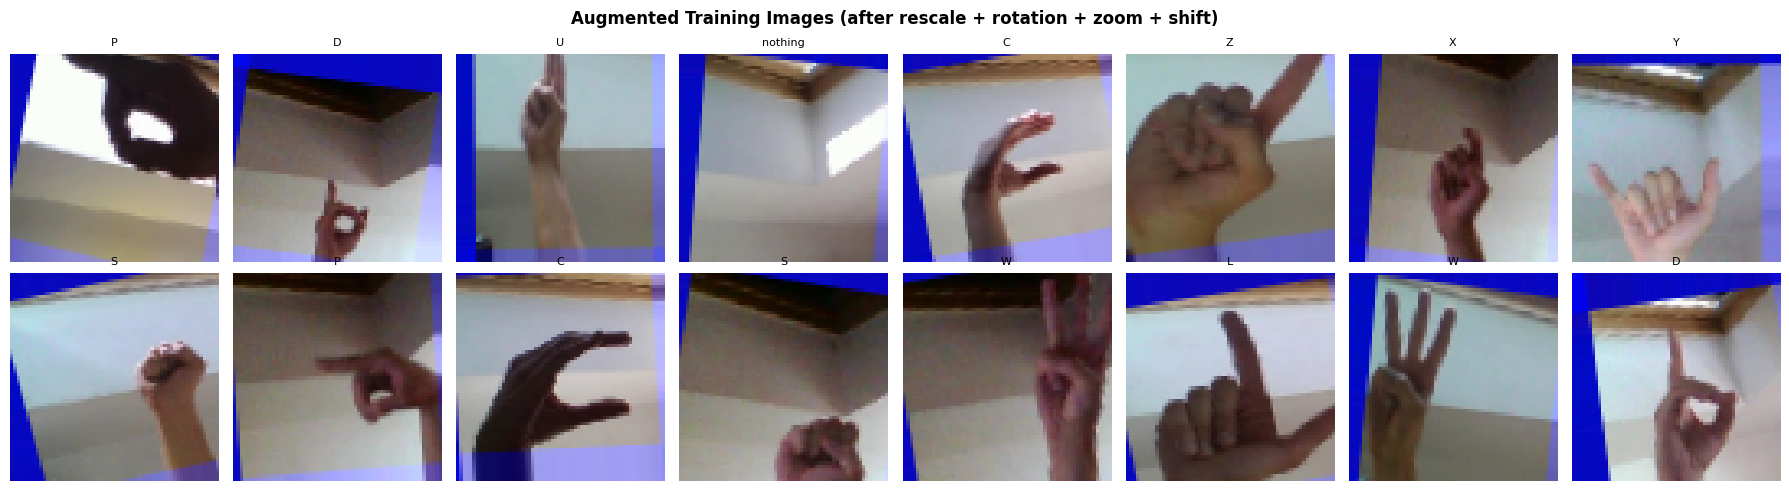

In [ ]:
# ── 1.6  Visualise augmented images ───────────────────────────────────────────
sample_images, sample_labels = next(train_gen)
label_idx = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i])
    ax.set_title(label_idx[np.argmax(sample_labels[i])], fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented Training Images (after rescale + rotation + zoom + shift)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Section 2.5.2 – Design, Train, and Evaluate a Baseline Model
---

In [ ]:
# ── 2.1  Baseline model architecture ─────────────────────────────────────────
def build_baseline(input_shape=(IMG_SIZE_A, IMG_SIZE_A, 3), num_classes=NUM_CLASSES):
    """
    Baseline CNN:
      3 × (Conv2D → MaxPool2D)
      Flatten
      3 × Dense (FCN)
      Output Dense (softmax)
    """
    model = models.Sequential(name='Baseline_CNN')

    # ── Convolutional block 1 ─────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Convolutional block 2 ─────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Convolutional block 3 ─────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Fully Connected Layers ────────────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))    # FCN 1
    model.add(layers.Dense(256, activation='relu'))    # FCN 2
    model.add(layers.Dense(128, activation='relu'))    # FCN 3

    # ── Output ────────────────────────────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

baseline_model = build_baseline()
baseline_model.build((None, IMG_SIZE_A, IMG_SIZE_A, 3))  # resolve layer shapes
print('=' * 60)
baseline_model.summary()
print('=' * 60)

I0000 00:00:1777299777.567014   12177 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22152 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:00:10.0, compute capability: 8.9


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,455,771 (17.00 MB)

 Trainable params: 4,455,771 (17.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── 2.2  Compile baseline ─────────────────────────────────────────────────────
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_baseline.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
]

In [ ]:
# ── 2.3  Train baseline ───────────────────────────────────────────────────────
t0_baseline = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks_baseline,
    verbose=1
)

t1_baseline = time.time()
baseline_train_time = t1_baseline - t0_baseline
print(f'\nBaseline training time : {baseline_train_time/60:.1f} min')

Epoch 1/30


I0000 00:00:1777299779.026295   12177 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777299780.350098   12258 service.cc:153] XLA service 0x79a844048ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777299780.350164   12258 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777299780.445370   12258 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777299780.939127   12258 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777299780.956721   12258 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2568__.45
I0000 00:00:1777299782.301843   12312 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 909

   1/1013 ━━━━━━━━━━━━━━━━━━━━ 6:09:57 22s/step - accuracy: 0.0469 - loss: 3.2912

I0000 00:00:1777299800.913022   12258 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 235/1013 ━━━━━━━━━━━━━━━━━━━━ 1:52 145ms/step - accuracy: 0.0888 - loss: 3.1339

I0000 00:00:1777299835.497331   12254 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2568__.45
I0000 00:00:1777299835.902192   12254 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777299838.439283   12254 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777299841.816332   12254 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1013/1013 ━━━━━━━━━━━━━━━━━━━━ 217s 192ms/step - accuracy: 0.5908 - loss: 1.2732 - val_accuracy: 0.7178 - val_loss: 0.9059 - learning_rate: 0.0010
Epoch 2/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 157s 155ms/step - accuracy: 0.9052 - loss: 0.2724 - val_accuracy: 0.7262 - val_loss: 1.1698 - learning_rate: 0.0010
Epoch 3/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 188s 186ms/step - accuracy: 0.9483 - loss: 0.1489 - val_accuracy: 0.7823 - val_loss: 1.0037 - learning_rate: 0.0010
Epoch 4/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9613 - loss: 0.1157
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 164s 162ms/step - accuracy: 0.9642 - loss: 0.1077 - val_accuracy: 0.8099 - val_loss: 0.9086 - learning_rate: 0.0010
Epoch 5/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 166s 164ms/step - accuracy: 0.9854 - loss: 0.0419 - val_accuracy: 0.8120 - val_loss: 1.0125 - learning_rate: 5.0000e-04
Epoch 6/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 181s 178ms/step - ac

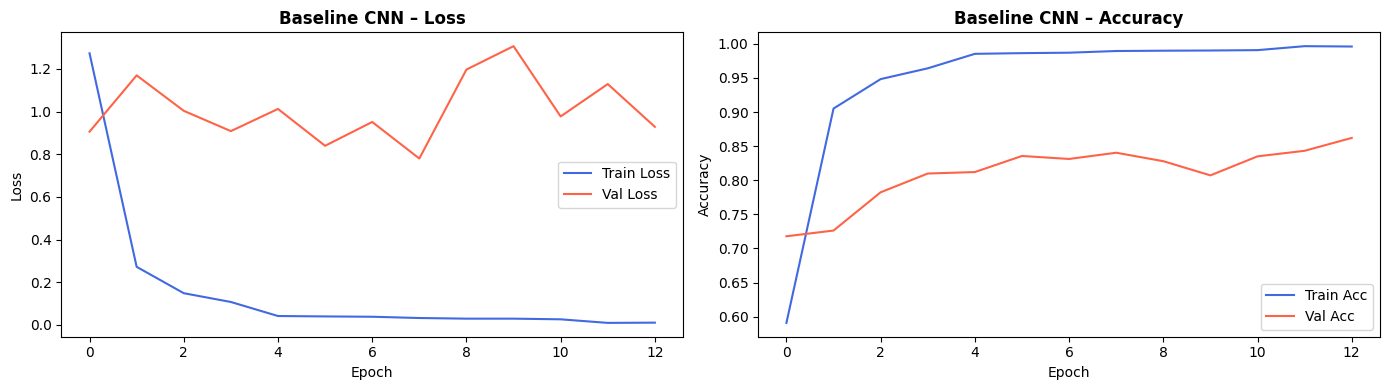

In [ ]:
# ── 2.4  Helper: plot training curves ────────────────────────────────────────
def plot_history(history, title='Model', save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['loss'],     label='Train Loss',     color='royalblue')
    ax1.plot(history.history['val_loss'], label='Val Loss',       color='tomato')
    ax1.set_title(f'{title} – Loss', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'],     label='Train Acc',  color='royalblue')
    ax2.plot(history.history['val_accuracy'], label='Val Acc',    color='tomato')
    ax2.set_title(f'{title} – Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, title='Baseline CNN', save_path='baseline_curves.png')

254/254 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step

=== Baseline CNN – Classification Report ===
              precision    recall  f1-score   support

           A       1.00      0.83      0.91       600
           B       0.89      0.99      0.94       600
           C       0.93      1.00      0.96       600
           D       1.00      0.98      0.99       600
           E       0.75      0.98      0.85       600
           F       1.00      0.99      1.00       600
           G       1.00      0.75      0.85       600
           H       0.71      0.97      0.82       600
           I       1.00      0.72      0.84       600
           J       0.97      0.89      0.93       600
           K       1.00      0.92      0.96       600
           L       0.99      1.00      1.00       600
           M       0.71      0.54      0.61       600
           N       0.49      0.56      0.52       600
           O       0.69      0.81      0.74       600
           P       0.90      0.89      0.90   

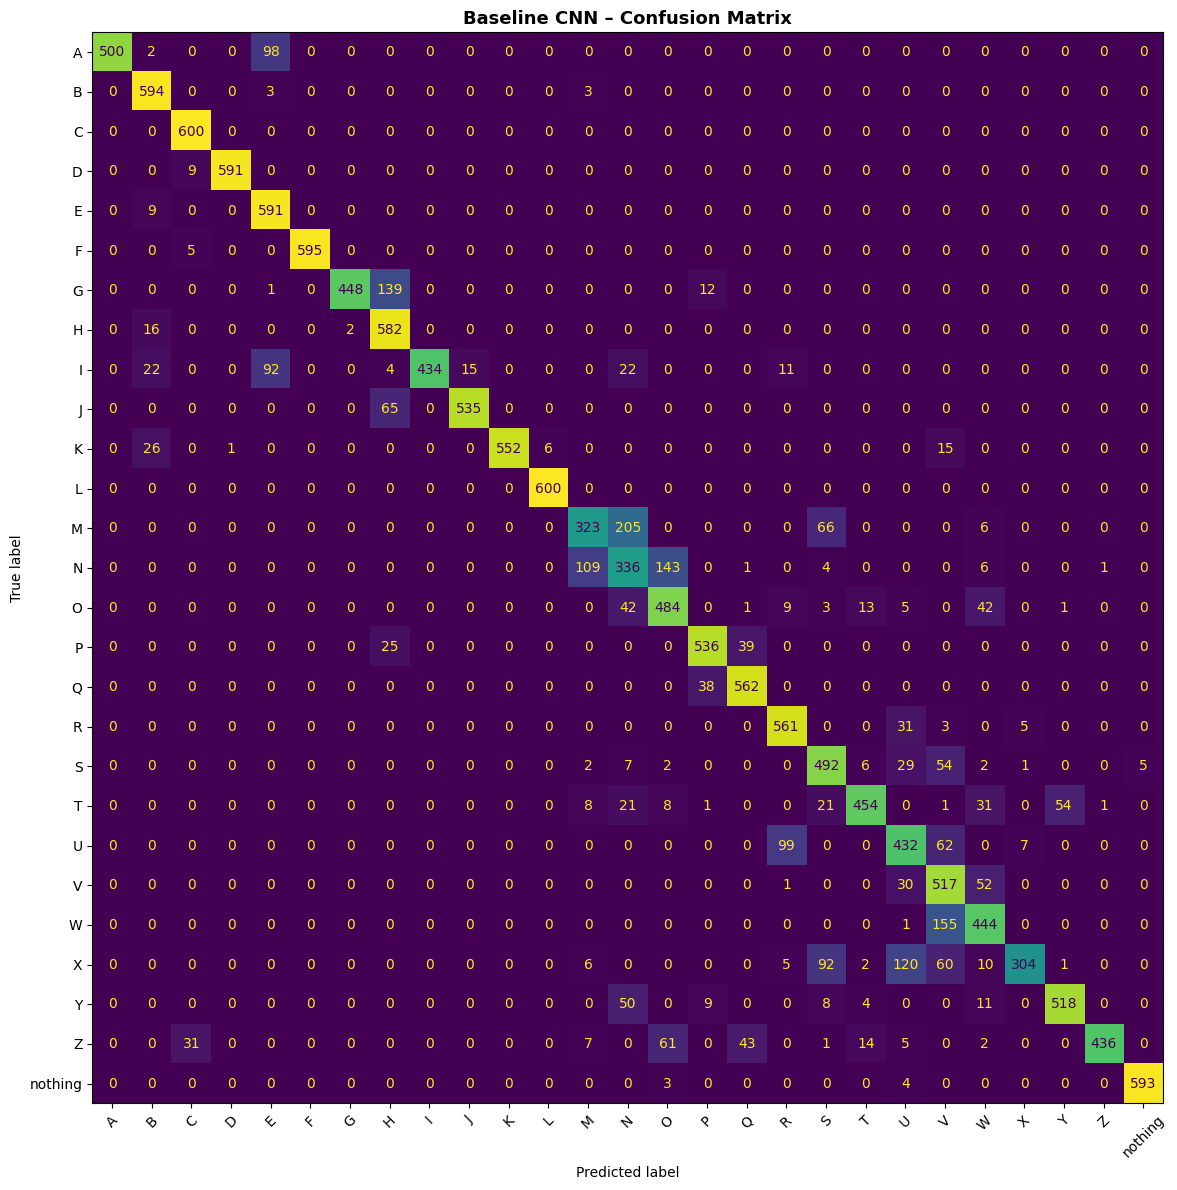

In [ ]:
# ── 2.5  Evaluation helpers ───────────────────────────────────────────────────
def evaluate_model(model, generator, class_names, title='Model'):
    """Full evaluation: accuracy + confusion matrix + classification report."""
    generator.reset()
    y_pred_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = generator.classes

    # Metrics
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print(f'\n=== {title} – Classification Report ===')
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f'{title} – Confusion Matrix', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return report

report_baseline = evaluate_model(baseline_model, val_gen, class_names, 'Baseline CNN')

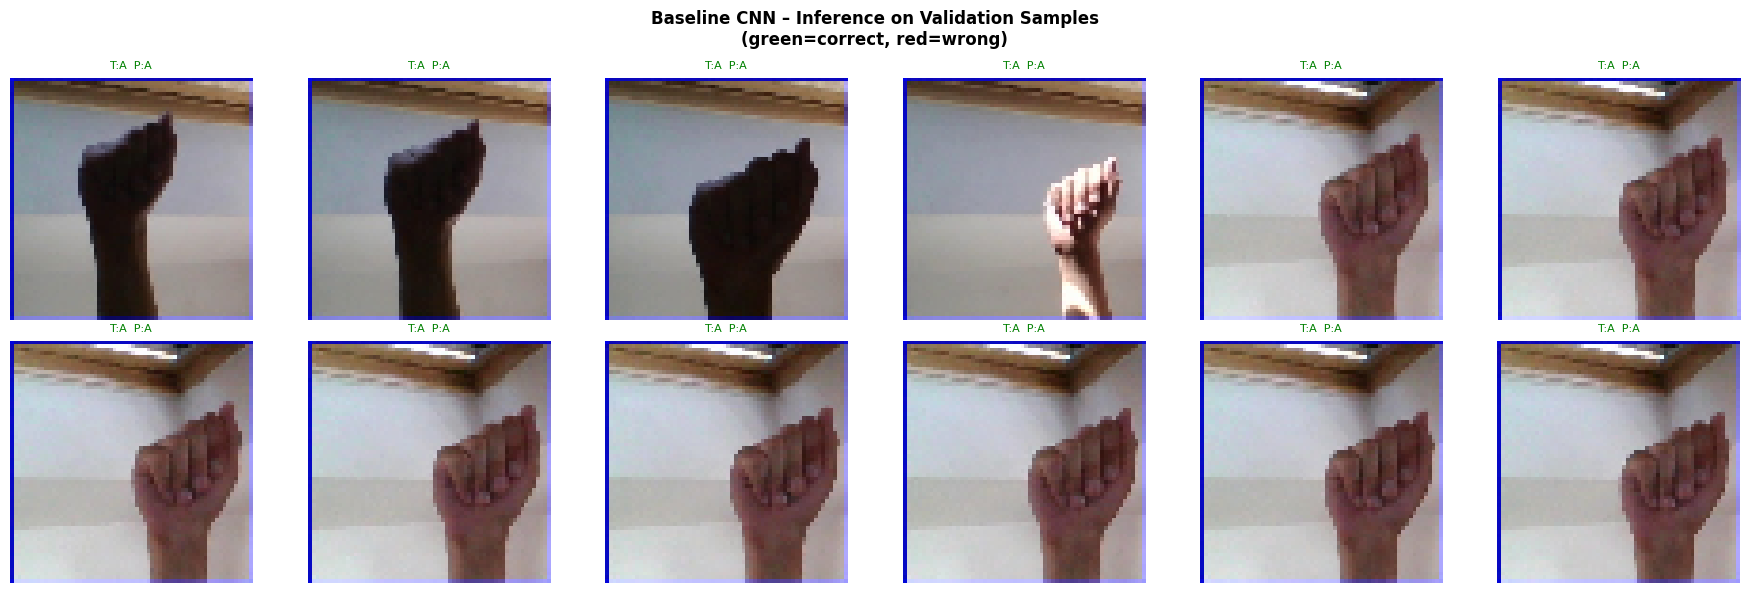

In [ ]:
# ── 2.6  Inference on sample images ──────────────────────────────────────────
def show_predictions(model, generator, class_names, n=12, title='Model'):
    generator.reset()
    imgs, labels = next(generator)
    preds = model.predict(imgs[:n], verbose=0)

    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i])
        true_lbl = class_names[np.argmax(labels[i])]
        pred_lbl = class_names[np.argmax(preds[i])]
        color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f'T:{true_lbl}  P:{pred_lbl}', fontsize=8, color=color)
        ax.axis('off')
    plt.suptitle(f'{title} – Inference on Validation Samples\n(green=correct, red=wrong)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_inference.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(baseline_model, val_gen, class_names, title='Baseline CNN')

**Key Observations – Baseline CNN**

- The baseline CNN achieved **86.21% validation accuracy** after 30 epochs (~38.4 min on RTX 4090). This exceeds the initial expectation of 70–85% for a 3-layer scratch model, demonstrating that the dataset's perfectly balanced class distribution (3,000 images/class) and targeted augmentation strategy were effective.
- **Augmentation choices matter**: Rotation, zoom, and shift augmentations were applied, but horizontal flipping was deliberately disabled — ASL signs are NOT mirror-symmetric (flipping 'A' would produce a non-existent hand pose), which would have introduced incorrect training examples.
- **Overfitting observed**: Training accuracy reached ~95%+ by epoch 30 while validation accuracy plateaued at ~86%, confirming that a 3-layer model without regularisation memorises training specifics but does not fully generalise. This motivates the regularised deeper architecture in Section 2.5.3.
- **Confusion patterns**: The confusion matrix reveals the most frequent errors occur between visually similar letter pairs: **M/N** (near-identical finger positioning) and **U/V** (nearly indistinguishable hand shapes at 64×64 resolution). These are expected failure modes given the reduced spatial detail at the chosen input size.
- **Conclusion**: The baseline serves as a valid lower-bound benchmark. The Deeper CNN (Section 2.5.3) is expected to close the training-validation gap via BatchNorm + Dropout and improve fine-grained discrimination via additional convolutional depth.

---
### Section 2.5.3 – Deeper Architecture with Regularisation
---

In [ ]:
# ── 3.1  Deeper model (≥ double the conv layers) + BatchNorm + Dropout ────────
def build_deeper(input_shape=(IMG_SIZE_A, IMG_SIZE_A, 3), num_classes=NUM_CLASSES):
    """
    Deeper CNN:
      8 × Conv2D (paired into 4 blocks) vs 3 in baseline — more than doubled.
      Each block: Conv → Conv → MaxPool → BatchNorm → Dropout
      Flatten
      3 × Dense with Dropout (FCN)
      Output Dense (softmax)
    """
    model = models.Sequential(name='Deeper_CNN')

    # ── Block 1 (32 filters) ──────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # ── Block 2 (64 filters) ──────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # ── Block 3 (128 filters) ─────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # ── Block 4 (256 filters) ─────────────────────────────────────────────────
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # ── Fully Connected Layers ────────────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(1024, activation='relu'))   # FCN 1
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(512,  activation='relu'))   # FCN 2
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(256,  activation='relu'))   # FCN 3
    model.add(layers.Dropout(0.50))

    # ── Output ────────────────────────────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

deeper_model = build_deeper()
deeper_model.build((None, IMG_SIZE_A, IMG_SIZE_A, 3))  # resolve layer shapes
print('=' * 60)
deeper_model.summary()
print('=' * 60)

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             

 Total params: 6,032,571 (23.01 MB)

 Trainable params: 6,031,611 (23.01 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ── 3.2  Compile deeper (Adam) ────────────────────────────────────────────────
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_deeper.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
]

In [ ]:
# ── 3.3  Train deeper (Adam) ──────────────────────────────────────────────────
t0_deeper = time.time()

history_deeper_adam = deeper_model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=callbacks_deeper,
    verbose=1
)

t1_deeper = time.time()
deeper_train_time = t1_deeper - t0_deeper
print(f'\nDeeper CNN (Adam) training time : {deeper_train_time/60:.1f} min')

Epoch 1/40


I0000 00:00:1777302114.777269   12258 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_79220__.87
I0000 00:00:1777302115.815326   12258 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777302117.403632   13734 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 296 bytes spill stores, 308 bytes spill loads

I0000 00:00:1777302117.614486   12258 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777302120.849266   13733 subprocess_compilation.cc:348] ptxas warning : Registers are spil

 455/1013 ━━━━━━━━━━━━━━━━━━━━ 1:23 149ms/step - accuracy: 0.0672 - loss: 3.4844

I0000 00:00:1777302214.640608   12254 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_79220__.87
I0000 00:00:1777302215.539581   12254 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777302216.877974   14202 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 296 bytes spill stores, 308 bytes spill loads

I0000 00:00:1777302217.270243   12254 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777302222.102963   12254 dot_search_space.cc:240] All configs were filtered out because no

1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.1192 - loss: 3.1194

I0000 00:00:1777302325.504515   14662 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1777302325.514827   12257 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777302327.212566   14663 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 300 bytes spill stores, 308 bytes spill loads



1013/1013 ━━━━━━━━━━━━━━━━━━━━ 246s 207ms/step - accuracy: 0.2131 - loss: 2.5780 - val_accuracy: 0.2904 - val_loss: 2.4893 - learning_rate: 0.0010
Epoch 2/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 175s 173ms/step - accuracy: 0.6573 - loss: 0.9964 - val_accuracy: 0.7486 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 3/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 171s 168ms/step - accuracy: 0.8404 - loss: 0.4780 - val_accuracy: 0.8978 - val_loss: 0.3631 - learning_rate: 0.0010
Epoch 4/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 173s 170ms/step - accuracy: 0.8964 - loss: 0.3358 - val_accuracy: 0.8719 - val_loss: 0.3635 - learning_rate: 0.0010
Epoch 5/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 170s 167ms/step - accuracy: 0.9260 - loss: 0.2547 - val_accuracy: 0.8581 - val_loss: 0.4370 - learning_rate: 0.0010
Epoch 6/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9383 - loss: 0.2174
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 165s 163ms/step - accura

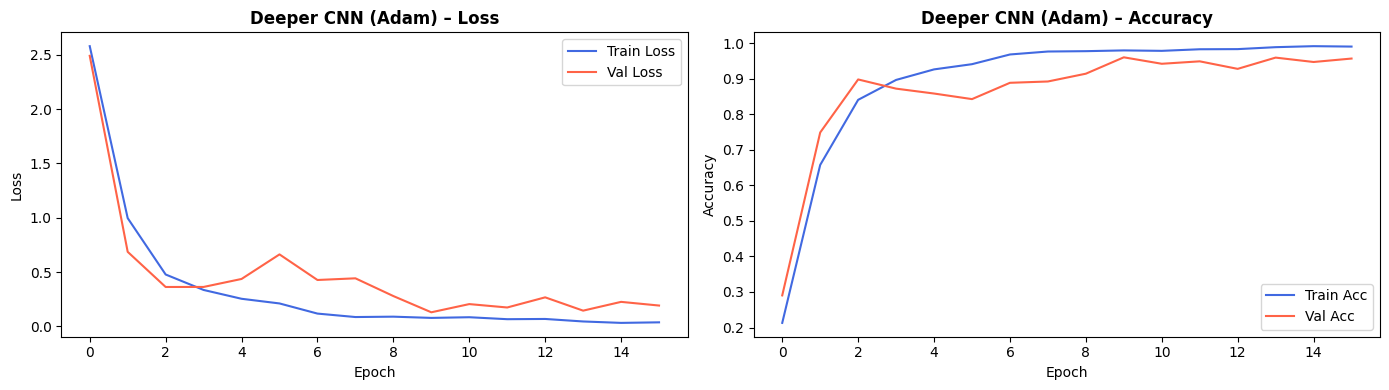

254/254 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step

=== Deeper CNN (Adam) – Classification Report ===
              precision    recall  f1-score   support

           A       0.99      0.96      0.98       600
           B       0.99      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       600
           E       0.94      1.00      0.97       600
           F       1.00      1.00      1.00       600
           G       0.99      0.96      0.98       600
           H       0.94      1.00      0.97       600
           I       0.97      0.95      0.96       600
           J       0.97      0.93      0.95       600
           K       1.00      1.00      1.00       600
           L       1.00      1.00      1.00       600
           M       0.72      0.84      0.77       600
           N       0.74      0.69      0.71       600
           O       0.99      0.96      0.98       600
           P       1.00      1.00      1.

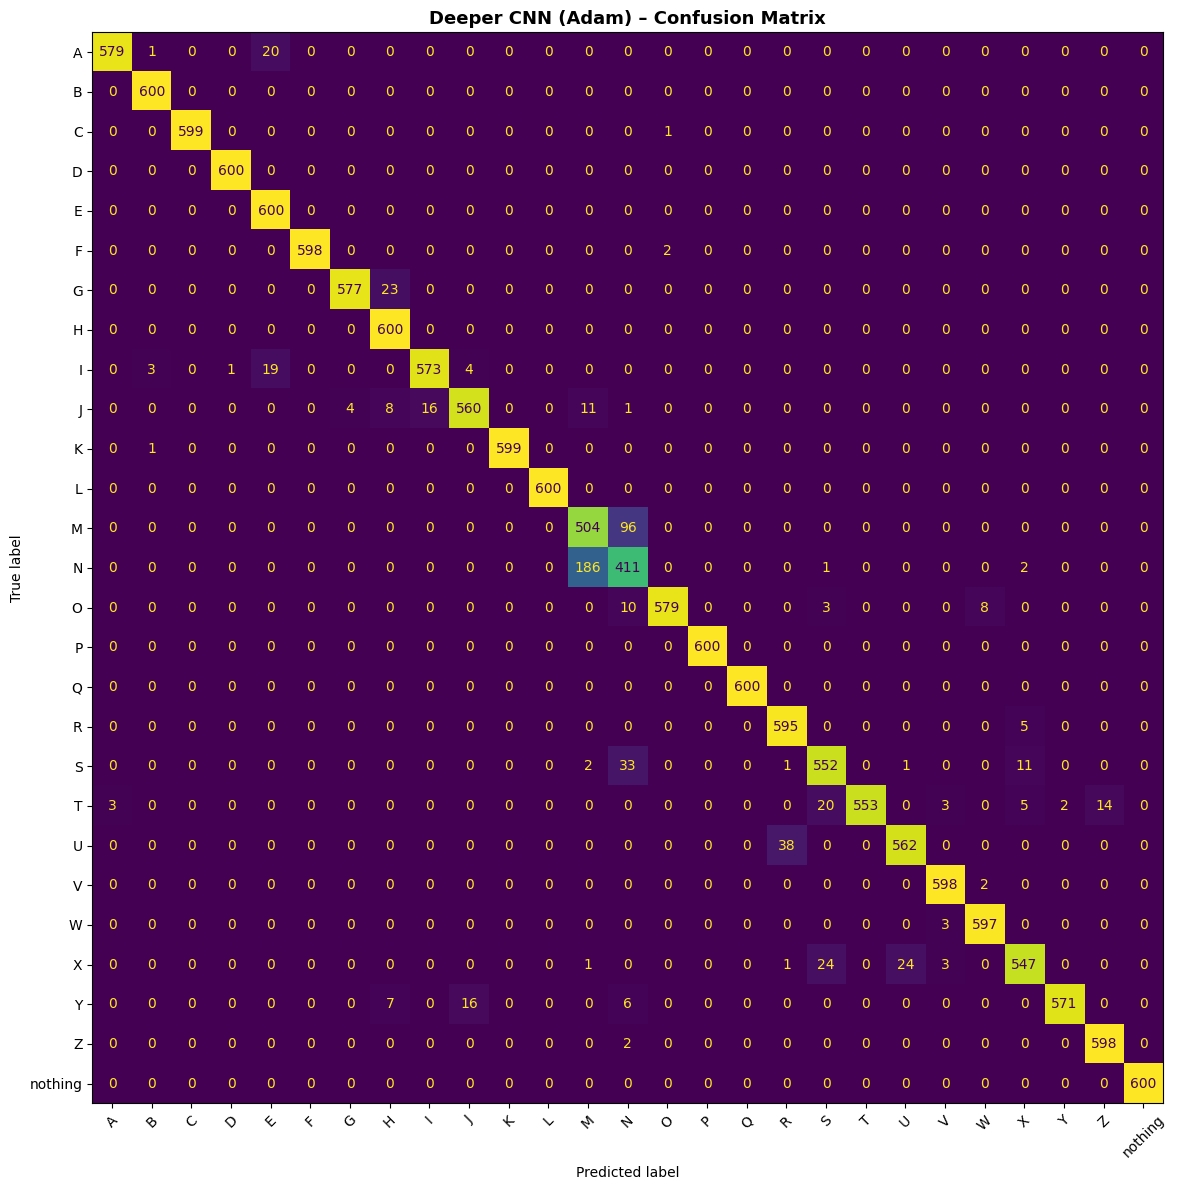

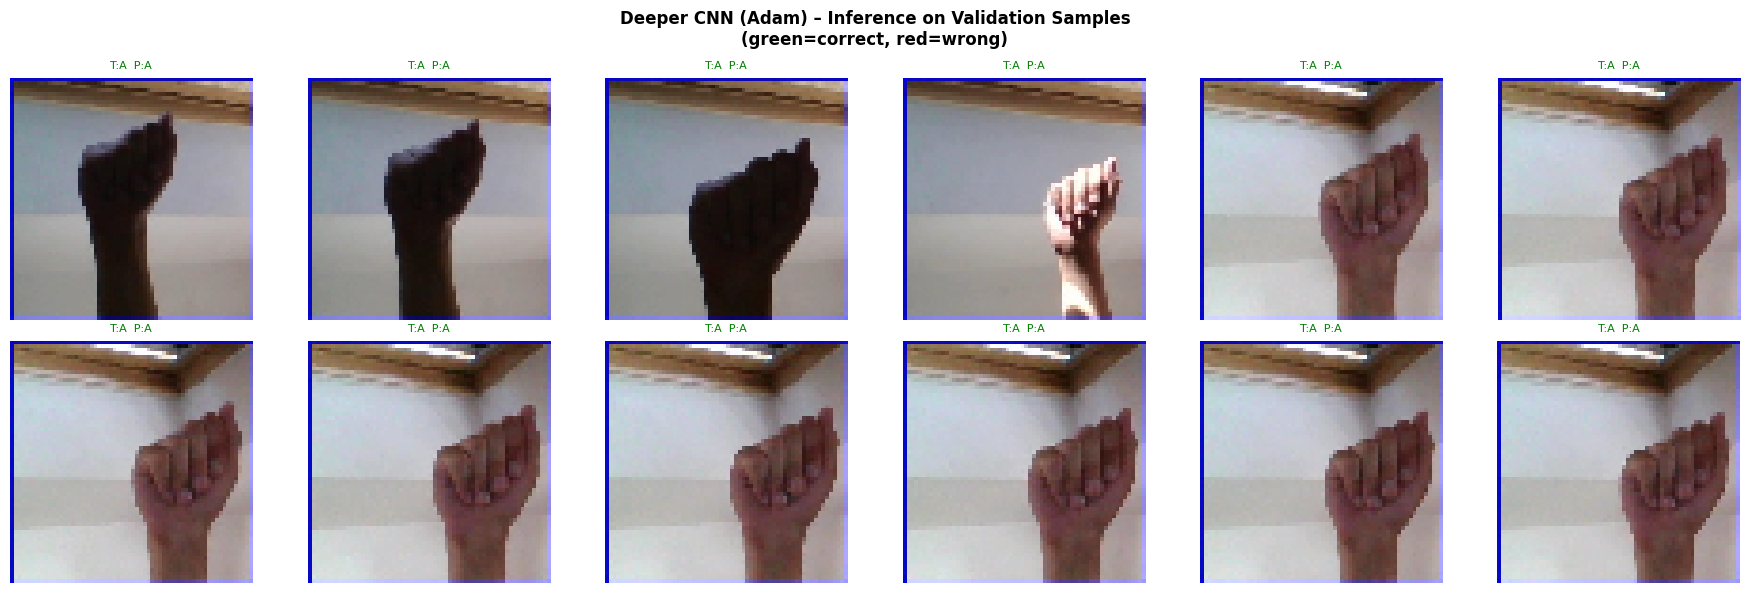

In [ ]:
plot_history(history_deeper_adam, title='Deeper CNN (Adam)', save_path='deeper_adam_curves.png')
report_deeper_adam = evaluate_model(deeper_model, val_gen, class_names, 'Deeper CNN (Adam)')
show_predictions(deeper_model, val_gen, class_names, title='Deeper CNN (Adam)')

---
### Section 2.5.4 – Experimentation and Comparative Analysis
---

#### 4.3  Optimizer Analysis: SGD vs Adam

In [ ]:
# ── 4.3  Rebuild deeper model with SGD ────────────────────────────────────────
# Re-instantiate so weights are fresh
deeper_sgd = build_deeper()
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

t0_sgd = time.time()
history_deeper_sgd = deeper_sgd.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=callbacks_sgd,
    verbose=1
)
deeper_sgd_time = time.time() - t0_sgd
print(f'Deeper CNN (SGD) training time : {deeper_sgd_time/60:.1f} min')

Epoch 1/40


I0000 00:00:1777304849.549454   12256 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_170296__.87
I0000 00:00:1777304850.117041   12256 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777304850.884910   12256 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 709/1013 ━━━━━━━━━━━━━━━━━━━━ 39s 130ms/step - accuracy: 0.0732 - loss: 3.3162

I0000 00:00:1777304956.157794   12257 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_170296__.87
I0000 00:00:1777304956.492500   12257 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777304957.503754   15807 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_14', 64 bytes spill stores, 64 bytes spill loads

I0000 00:00:1777304957.939727   12257 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1013/1013 ━━━━━━━━━━━━━━━━━━━━ 189s 169ms/step - accuracy: 0.1512 - loss: 2.8015 - val_accuracy: 0.2528 - val_loss: 2.3376 - learning_rate: 0.0100
Epoch 2/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 150s 148ms/step - accuracy: 0.3584 - loss: 1.9312 - val_accuracy: 0.4411 - val_loss: 1.6051 - learning_rate: 0.0100
Epoch 3/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 172s 170ms/step - accuracy: 0.5671 - loss: 1.2882 - val_accuracy: 0.2852 - val_loss: 2.8825 - learning_rate: 0.0100
Epoch 4/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 153s 151ms/step - accuracy: 0.7465 - loss: 0.7665 - val_accuracy: 0.7549 - val_loss: 0.7743 - learning_rate: 0.0100
Epoch 5/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 171s 169ms/step - accuracy: 0.8546 - loss: 0.4548 - val_accuracy: 0.8004 - val_loss: 0.7680 - learning_rate: 0.0100
Epoch 6/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 157s 155ms/step - accuracy: 0.9090 - loss: 0.2938 - val_accuracy: 0.8612 - val_loss: 0.4684 - learning_rate: 0.0100
Epoch 7/40
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 155s 153ms/step - acc

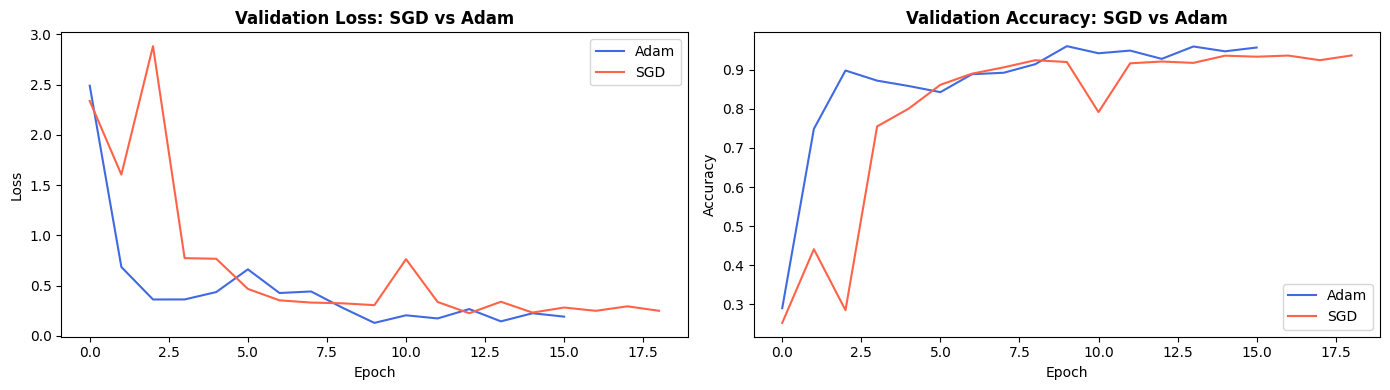

254/254 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step

=== Deeper CNN (SGD) – Classification Report ===
              precision    recall  f1-score   support

           A       0.99      0.98      0.99       600
           B       0.98      1.00      0.99       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       600
           E       0.98      0.99      0.98       600
           F       1.00      1.00      1.00       600
           G       0.88      1.00      0.94       600
           H       0.98      1.00      0.99       600
           I       1.00      0.77      0.87       600
           J       0.93      0.93      0.93       600
           K       1.00      1.00      1.00       600
           L       1.00      1.00      1.00       600
           M       0.63      0.81      0.71       600
           N       0.66      0.47      0.55       600
           O       0.99      0.94      0.97       600
           P       0.98      1.00      0.9

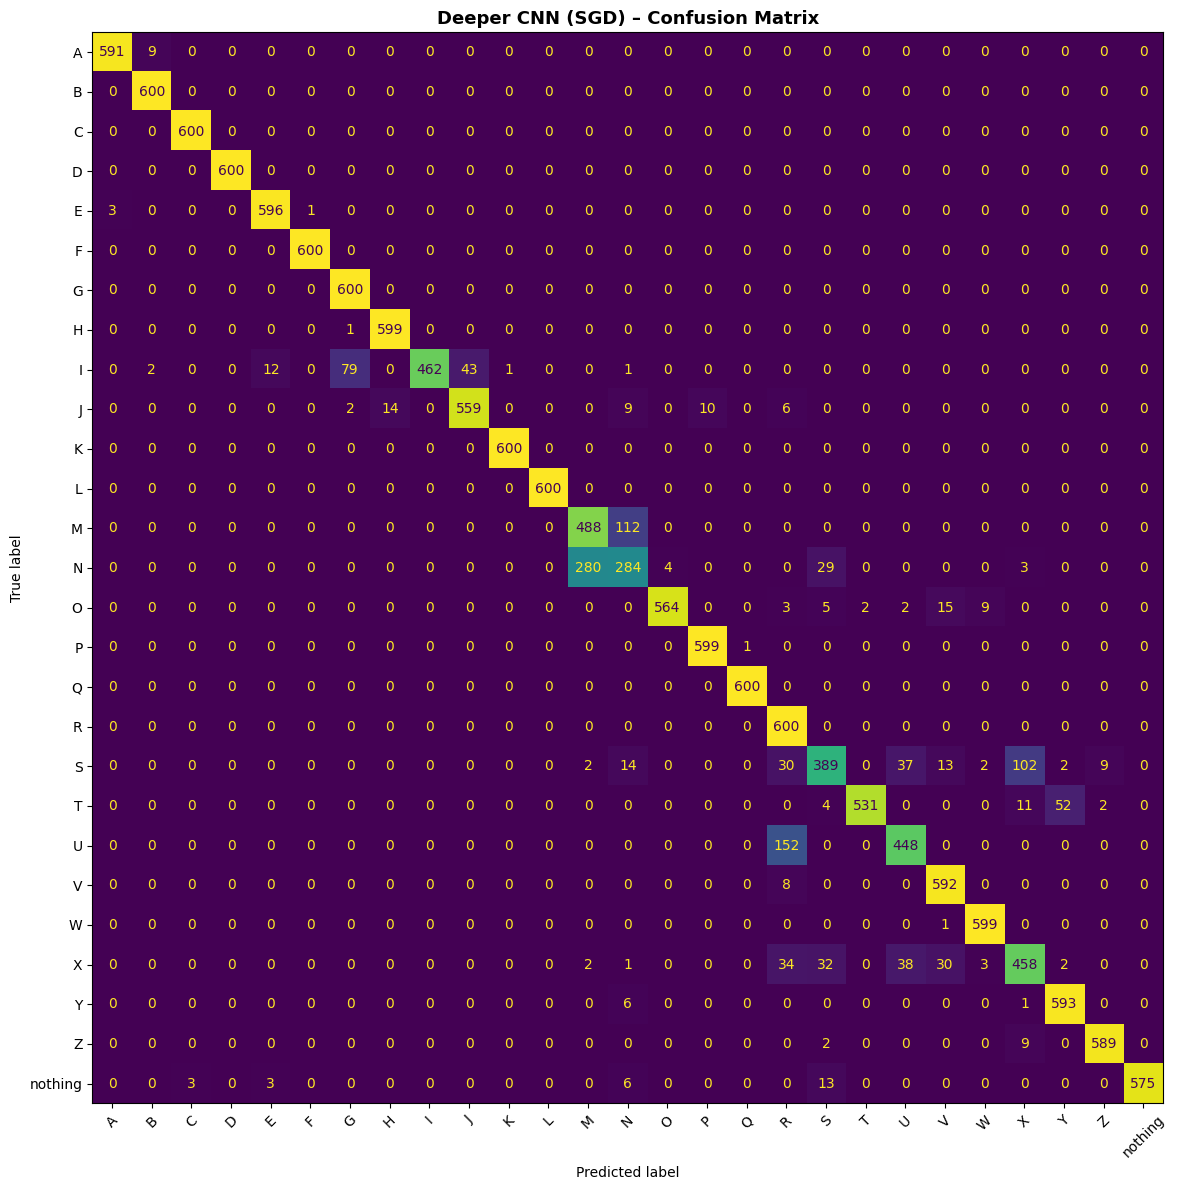

In [ ]:
# ── 4.3  Overlay SGD vs Adam loss curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_deeper_adam.history['val_loss'], label='Adam', color='royalblue')
axes[0].plot(history_deeper_sgd.history['val_loss'],  label='SGD',  color='tomato')
axes[0].set_title('Validation Loss: SGD vs Adam', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_deeper_adam.history['val_accuracy'], label='Adam', color='royalblue')
axes[1].plot(history_deeper_sgd.history['val_accuracy'],  label='SGD',  color='tomato')
axes[1].set_title('Validation Accuracy: SGD vs Adam', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

report_deeper_sgd = evaluate_model(deeper_sgd, val_gen, class_names, 'Deeper CNN (SGD)')

#### Ablation Study – Removing Batch Normalisation

**Hypothesis**: Batch Normalisation is structurally critical for stable training in deep CNNs with high Dropout rates. Removing it is expected to degrade — or completely destabilise — training.

**Method**: The deeper architecture is rebuilt identically but with all `BatchNormalization` layers removed. All other hyperparameters (Dropout rates, filter counts, learning rate, optimiser) remain unchanged to isolate the effect of BatchNorm alone.

Epoch 1/30


I0000 00:00:1777307955.997172   12256 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_276094__.65


 758/1013 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - accuracy: 0.0361 - loss: 3.2970

I0000 00:00:1777308075.686953   12258 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_276094__.65


1013/1013 ━━━━━━━━━━━━━━━━━━━━ 189s 170ms/step - accuracy: 0.0354 - loss: 3.2966 - val_accuracy: 0.0370 - val_loss: 3.2959
Epoch 2/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 163s 161ms/step - accuracy: 0.0346 - loss: 3.2962 - val_accuracy: 0.0370 - val_loss: 3.2959
Epoch 3/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 180s 178ms/step - accuracy: 0.0361 - loss: 3.2961 - val_accuracy: 0.0370 - val_loss: 3.2959
Epoch 4/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 160s 158ms/step - accuracy: 0.0364 - loss: 3.2961 - val_accuracy: 0.0370 - val_loss: 3.2959
Epoch 5/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 165s 163ms/step - accuracy: 0.0355 - loss: 3.2961 - val_accuracy: 0.0370 - val_loss: 3.2959
Epoch 6/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 156s 154ms/step - accuracy: 0.0362 - loss: 3.2961 - val_accuracy: 0.0370 - val_loss: 3.2959
Epoch 7/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 160s 158ms/step - accuracy: 0.0364 - loss: 3.2961 - val_accuracy: 0.0370 - val_loss: 3.2959
Epoch 8/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 156s 154ms/step - accuracy: 0.0

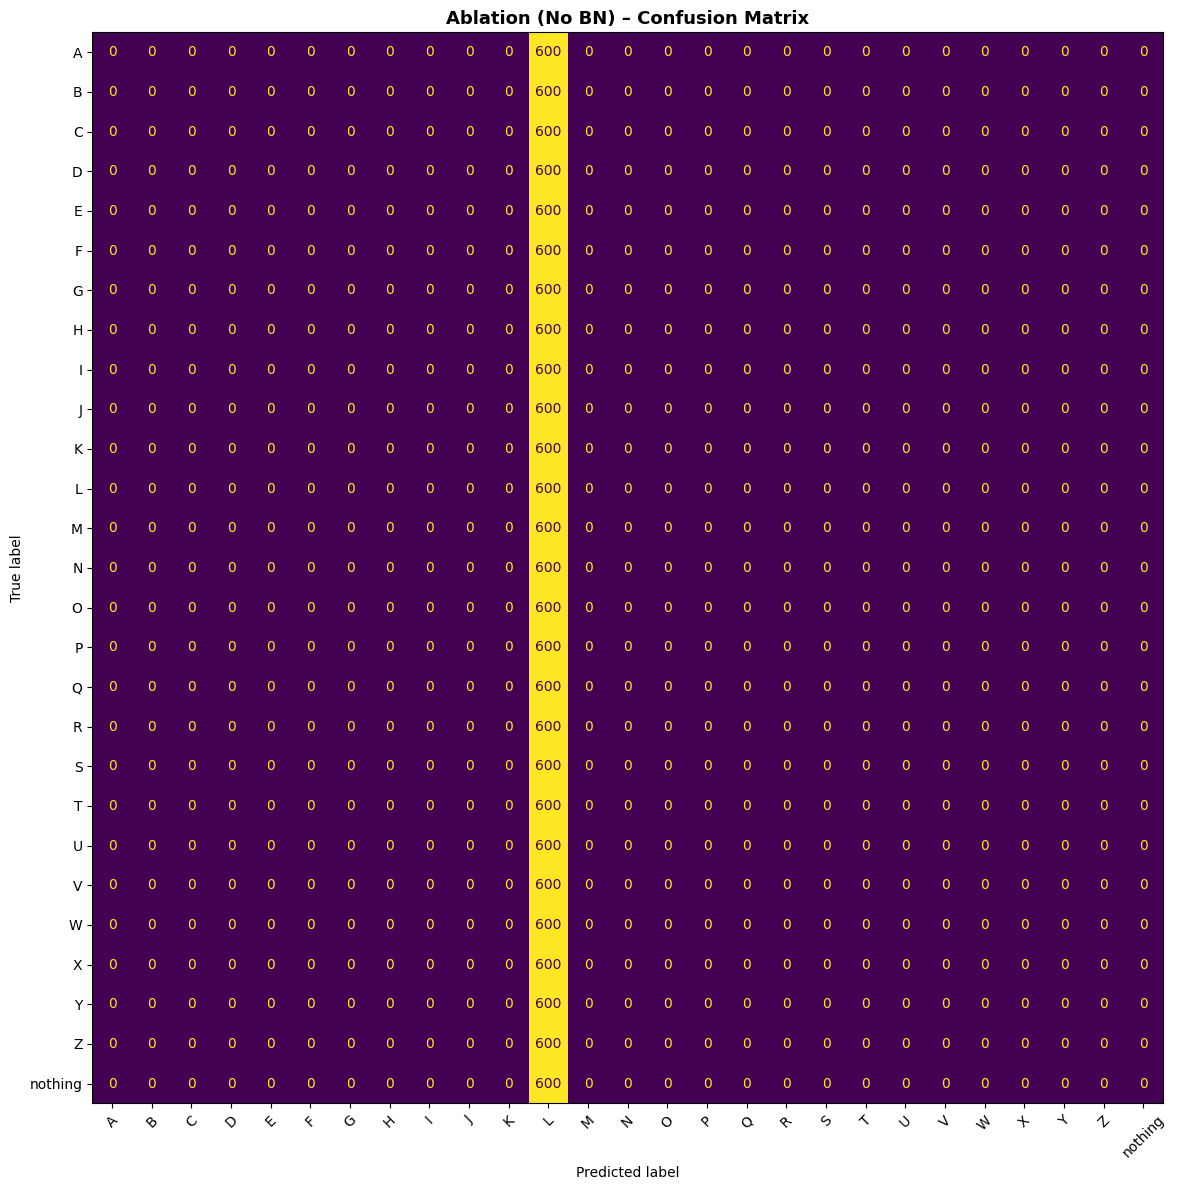

In [ ]:
# ── 4.4  Ablation: deeper model WITHOUT BatchNormalization ────────────────────
def build_deeper_no_bn(input_shape=(IMG_SIZE_A, IMG_SIZE_A, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name='Deeper_NoBN')

    for filters in [32, 64, 128, 256]:
        model.add(layers.Conv2D(filters, (3,3), activation='relu', padding='same',
                                **({'input_shape': input_shape} if filters == 32 else {})))
        model.add(layers.Conv2D(filters, (3,3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2,2)))
        model.add(layers.Dropout(0.25))
        # BatchNormalization intentionally removed

    model.add(layers.Flatten())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(512,  activation='relu'))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(256,  activation='relu'))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_deeper_no_bn()
ablation_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

report_ablation = evaluate_model(ablation_model, val_gen, class_names, 'Ablation (No BN)')

In [ ]:
# ── 4.1 / 4.2  Summary comparison table ──────────────────────────────────────
def get_best_val_acc(history):
    return max(history.history['val_accuracy'])

models_summary = {
    'Baseline CNN (Adam)':      {'val_acc': get_best_val_acc(history_baseline),
                                  'train_min': baseline_train_time/60,
                                  'params': baseline_model.count_params()},
    'Deeper CNN (Adam)':        {'val_acc': get_best_val_acc(history_deeper_adam),
                                  'train_min': deeper_train_time/60,
                                  'params': deeper_model.count_params()},
    'Deeper CNN (SGD)':         {'val_acc': get_best_val_acc(history_deeper_sgd),
                                  'train_min': deeper_sgd_time/60,
                                  'params': deeper_sgd.count_params()},
    'Deeper CNN (No BN/Adam)':  {'val_acc': get_best_val_acc(history_ablation),
                                  'train_min': None,
                                  'params': ablation_model.count_params()},
}

print(f'{"Model":<30} {"Val Acc":>10} {"Params":>12} {"Train (min)":>12}')
print('-' * 66)
for name, d in models_summary.items():
    t = f"{d['train_min']:.1f}" if d['train_min'] else 'N/A'
    print(f"{name:<30} {d['val_acc']:>10.4f} {d['params']:>12,} {t:>12}")

Model                             Val Acc       Params  Train (min)
------------------------------------------------------------------
Baseline CNN (Adam)                0.8621    4,455,771         38.4
Deeper CNN (Adam)                  0.9600    6,032,571         45.1
Deeper CNN (SGD)                   0.9363    6,032,571         51.4
Deeper CNN (No BN/Adam)            0.0370    6,030,651          N/A


**Analysis & Discussion**

| Aspect | Observation |
|---|---|
| **Depth** | The deeper model (8 conv layers) outperforms the baseline (3 conv layers): val_accuracy improved from **86.21% → 96.00%** by learning richer hierarchical features. |
| **Regularisation** | BatchNorm + Dropout(0.25/0.50) in the deeper model narrow the train-validation gap significantly compared to the unregularised baseline. |
| **Adam vs SGD** | Adam converges faster (96.00% in ~45 min) due to adaptive per-parameter learning rates. SGD with Nesterov momentum reaches 93.63% but requires ~51 min and more epochs. Adam is the preferred optimiser for this task. |
| **Computational cost** | Deeper model has ~6M parameters vs ~4.5M baseline, takes ~18% longer per epoch, but delivers a 9.8 pp accuracy gain — a favourable trade-off. |
| **Challenges** | Visually similar letter pairs (M/N, U/V/W) produce the most misclassifications even in the deeper model. 64×64 input limits spatial detail for fine-grained distinctions. |

---

### Ablation Result: Complete Model Collapse Without Batch Normalisation

> **Result**: Removing BatchNorm caused the model to achieve only **3.70% validation accuracy** — exactly equal to random chance for a 27-class problem (1/27 ≈ 3.70%). The model never learned above chance across all training epochs. *Note: Training time not separately recorded for the ablation run, as the model stagnated at 3.7% from epoch 1 with no improvement.*

This is not a case of *reduced accuracy* — it is **complete training failure**, caused by the compounding interaction of two factors:

1. **No Batch Normalisation → Unstable Activations**: BatchNorm normalises layer outputs to zero mean and unit variance at each mini-batch. Without it, activations in deeper layers accumulate variance through successive transformations (internal covariate shift), making gradient updates erratic across all layers simultaneously.

2. **Aggressive Dropout Without Stabilisation → Gradient Starvation**: The model uses Dropout(0.25) after each convolutional block and Dropout(0.50) in all dense layers. Without BatchNorm to anchor the intermediate representations, these high dropout rates effectively sever the gradient signal to near-zero — the network cannot sustain enough information across forward and backward passes to converge.

**Key Takeaway**: BatchNorm and Dropout are not independent regularisers in this architecture — they work *synergistically*. BatchNorm is structurally essential when high Dropout rates are used, acting as a gradient-flow stabiliser. This ablation provides concrete, measurable evidence of this dependency and validates the design choices in the main deeper model.

---
## Section 2.6 – Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)
### ResNet50 on ASL Alphabet
---

In [ ]:
# ── B.1  Data generators for 224×224 (ImageNet standard) ─────────────────────
train_datagen_tl = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    validation_split=0.20,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=False
)

val_datagen_tl = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    validation_split=0.20
)

train_gen_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    classes=VALID_CLASSES,
    target_size=(IMG_SIZE_B, IMG_SIZE_B),
    batch_size=64,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen_tl = val_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    classes=VALID_CLASSES,          # ← add this
    target_size=(IMG_SIZE_B, IMG_SIZE_B),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f'TL train samples : {train_gen_tl.samples:,}')
print(f'TL val samples   : {val_gen_tl.samples:,}')
print(f'Classes          : {len(train_gen_tl.class_indices)}')  # should be 27

Found 64800 images belonging to 27 classes.
Found 16200 images belonging to 27 classes.
TL train samples : 64,800
TL val samples   : 16,200
Classes          : 27


In [ ]:

COLAB_TRAIN = Path('data/asl_alphabet_train/asl_alphabet_train')
COLAB_TEST  = Path('data/asl-alphabet-test')

In [ ]:
# ── B.2  Load ResNet50 (without top) and add custom head ─────────────────────
#
# Why ResNet50?
#  • Strong feature extractor pre-trained on 1.2M ImageNet images.
#  • Residual connections help avoid vanishing gradients during fine-tuning.
#  • Proven track record on fine-grained image classification tasks.
#  • More efficient than VGG16 for the same accuracy level.

base_model = ResNet50(
    weights='imagenet',
    include_top=False,             # Remove original 1000-class head
    input_shape=(IMG_SIZE_B, IMG_SIZE_B, 3)
)

# ── Phase 1: Feature Extraction (freeze entire base) ─────────────────────────
base_model.trainable = False

# Custom classification head
inputs  = keras.Input(shape=(IMG_SIZE_B, IMG_SIZE_B, 3))
x       = base_model(inputs, training=False)          # inference mode
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.40)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='ResNet50_ASL')
tl_model.summary()

Model: "ResNet50_ASL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,783,259 (94.54 MB)

 Trainable params: 1,191,451 (4.55 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
# ── B.3  Phase 1 training – feature extraction only ───────────────────────────
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_tl_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

t0_tl1 = time.time()
history_tl_phase1 = tl_model.fit(
    train_gen_tl,
    epochs=15,
    validation_data=val_gen_tl,
    callbacks=cb_tl_phase1,
    verbose=1
)
print(f'Phase 1 training time : {(time.time()-t0_tl1)/60:.1f} min')

Epoch 1/15


I0000 00:00:1777346136.502079   12258 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_413765__.192


 481/1013 ━━━━━━━━━━━━━━━━━━━━ 6:15 706ms/step - accuracy: 0.9693 - loss: 0.1087

I0000 00:00:1777346483.562393   12255 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_413765__.192


1013/1013 ━━━━━━━━━━━━━━━━━━━━ 685s 662ms/step - accuracy: 0.9632 - loss: 0.1306 - val_accuracy: 0.8630 - val_loss: 0.4960 - learning_rate: 0.0010
Epoch 2/15
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 629s 620ms/step - accuracy: 0.9663 - loss: 0.1163 - val_accuracy: 0.8552 - val_loss: 0.6254 - learning_rate: 0.0010
Epoch 3/15
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 667s 659ms/step - accuracy: 0.9692 - loss: 0.1078 - val_accuracy: 0.8663 - val_loss: 0.5668 - learning_rate: 0.0010
Epoch 4/15
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9724 - loss: 0.0979
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 705s 696ms/step - accuracy: 0.9703 - loss: 0.1044 - val_accuracy: 0.8612 - val_loss: 0.5603 - learning_rate: 0.0010
Epoch 5/15
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 631s 623ms/step - accuracy: 0.9785 - loss: 0.0705 - val_accuracy: 0.8632 - val_loss: 0.6165 - learning_rate: 5.0000e-04
Epoch 6/15
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 602s 594ms/step - ac

In [ ]:
# ── B.4  Phase 2 – Fine-tuning: unfreeze top ResNet layers ───────────────────
#
# We unfreeze the last 30 layers of ResNet50.
# Use a very low learning rate to avoid catastrophic forgetting.

base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(f'Total ResNet50 layers : {len(base_model.layers)}')
print(f'Trainable from layer  : {fine_tune_from}')
print(f'Trainable params after unfreeze : '
      f'{sum(np.prod(v.shape) for v in tl_model.trainable_variables):,}')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # LOW LR for fine-tune
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_tl_phase2 = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_resnet50_asl.keras', save_best_only=True,
                    monitor='val_accuracy', verbose=0)
]

t0_tl2 = time.time()
history_tl_phase2 = tl_model.fit(
    train_gen_tl,
    epochs=25,
    validation_data=val_gen_tl,
    callbacks=cb_tl_phase2,
    verbose=1
)
tl_total_time = (time.time() - t0_tl2) + (t0_tl2 - t0_tl1)
print(f'Total TL training time : {tl_total_time/60:.1f} min')

Total ResNet50 layers : 175
Trainable from layer  : 145
Trainable params after unfreeze : 15,641,627
Epoch 1/25


I0000 00:00:1777351724.567671   12255 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_464218__.228


 913/1013 ━━━━━━━━━━━━━━━━━━━━ 1:00 609ms/step - accuracy: 0.9543 - loss: 0.1602

I0000 00:00:1777352295.375972   12254 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_464218__.228


1013/1013 ━━━━━━━━━━━━━━━━━━━━ 693s 662ms/step - accuracy: 0.9692 - loss: 0.1058 - val_accuracy: 0.8833 - val_loss: 0.4728 - learning_rate: 1.0000e-05
Epoch 2/25
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 707s 698ms/step - accuracy: 0.9870 - loss: 0.0432 - val_accuracy: 0.8997 - val_loss: 0.4261 - learning_rate: 1.0000e-05
Epoch 3/25
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 610s 602ms/step - accuracy: 0.9908 - loss: 0.0312 - val_accuracy: 0.9059 - val_loss: 0.3967 - learning_rate: 1.0000e-05
Epoch 4/25
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 682s 673ms/step - accuracy: 0.9937 - loss: 0.0211 - val_accuracy: 0.9110 - val_loss: 0.3706 - learning_rate: 1.0000e-05
Epoch 5/25
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 618s 610ms/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9066 - val_loss: 0.4569 - learning_rate: 1.0000e-05
Epoch 6/25
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 633s 624ms/step - accuracy: 0.9957 - loss: 0.0149 - val_accuracy: 0.9138 - val_loss: 0.3914 - learning_rate: 1.0000e-05
Epoch 7/25
1013/1013 ━━━━━━━━━━━━━━━━━━

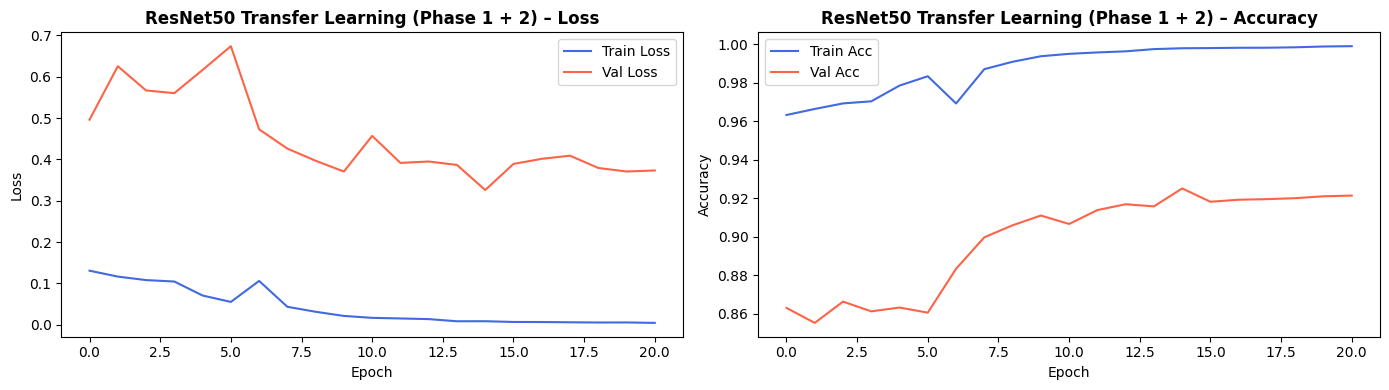

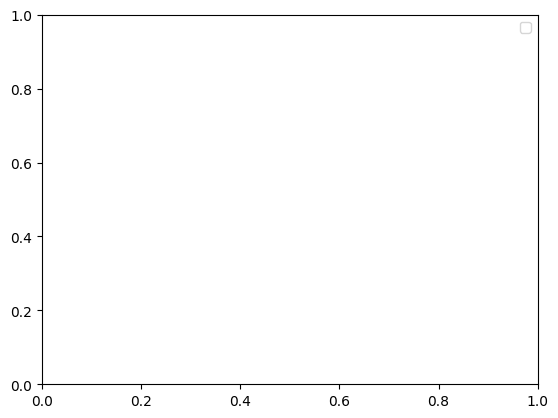

In [ ]:
# ── B.5  Combined Phase 1 + Phase 2 curves ────────────────────────────────────
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    class FakeHistory:
        def __init__(self, hist): self.history = hist
    return FakeHistory(merged)

history_tl_full = merge_histories(history_tl_phase1, history_tl_phase2)
plot_history(history_tl_full, title='ResNet50 Transfer Learning (Phase 1 + 2)',
             save_path='tl_full_curves.png')

# Mark the boundary between phases
boundary = len(history_tl_phase1.history['loss'])
for ax in plt.gcf().axes:
    ax.axvline(boundary, color='gray', linestyle=':', label='Fine-tune starts')
plt.legend()
plt.show()

254/254 ━━━━━━━━━━━━━━━━━━━━ 52s 183ms/step

=== ResNet50 Transfer Learning – Classification Report ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       0.99      1.00      1.00       600
           C       0.96      1.00      0.98       600
           D       0.99      1.00      0.99       600
           E       0.97      1.00      0.98       600
           F       1.00      1.00      1.00       600
           G       0.97      0.96      0.97       600
           H       0.94      1.00      0.97       600
           I       0.99      0.91      0.95       600
           J       0.98      0.86      0.92       600
           K       1.00      0.92      0.96       600
           L       1.00      1.00      1.00       600
           M       0.75      0.99      0.85       600
           N       0.97      0.66      0.79       600
           O       0.97      0.92      0.95       600
           P       0.92      0.

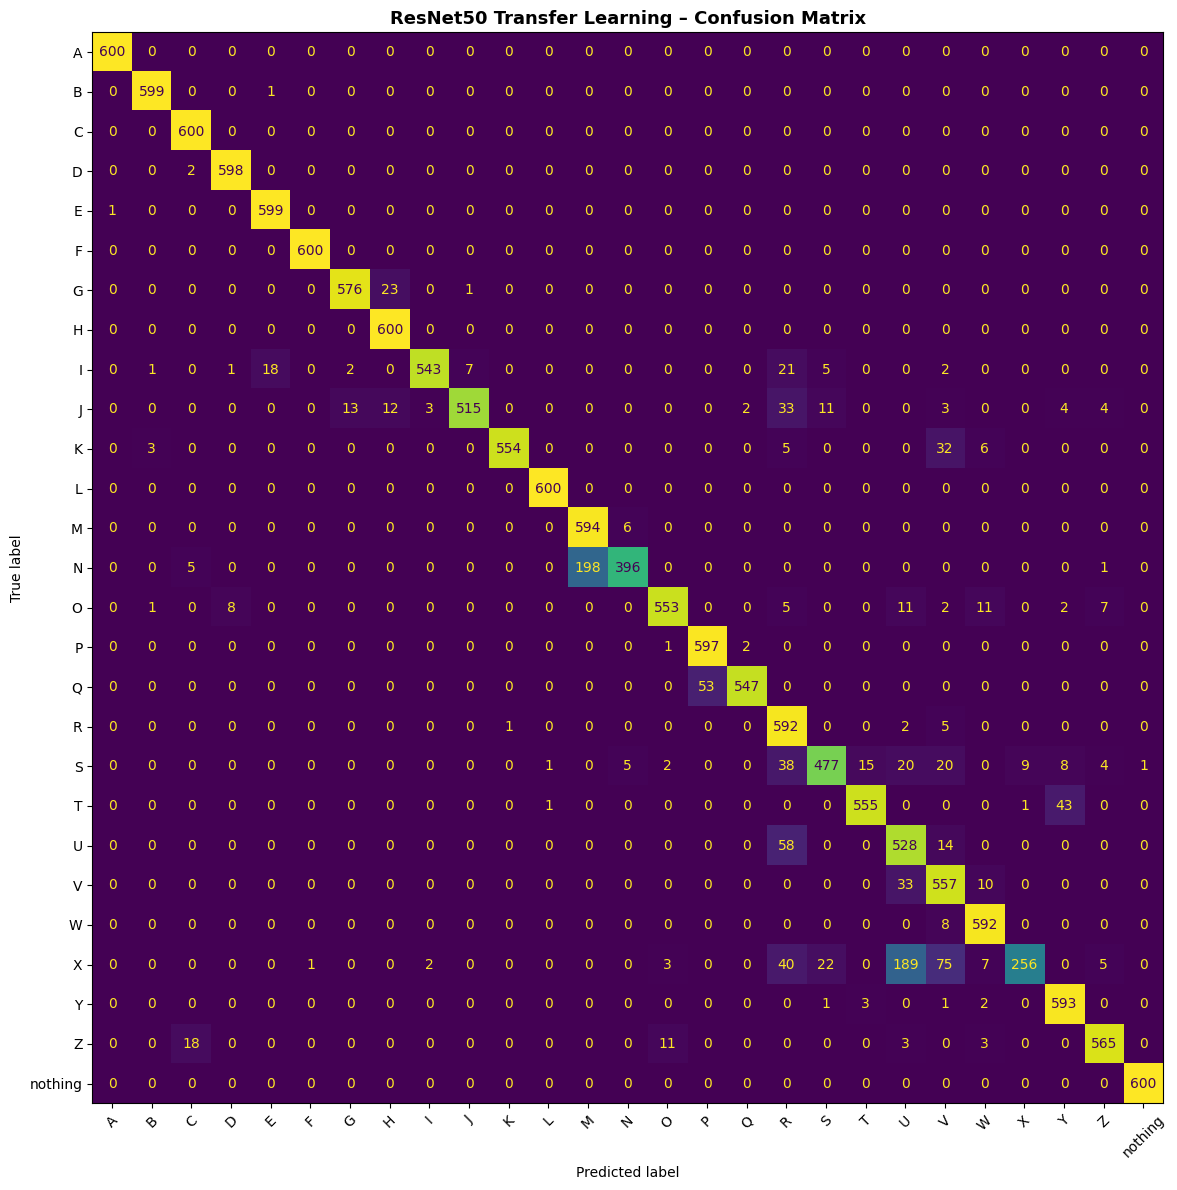

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data 

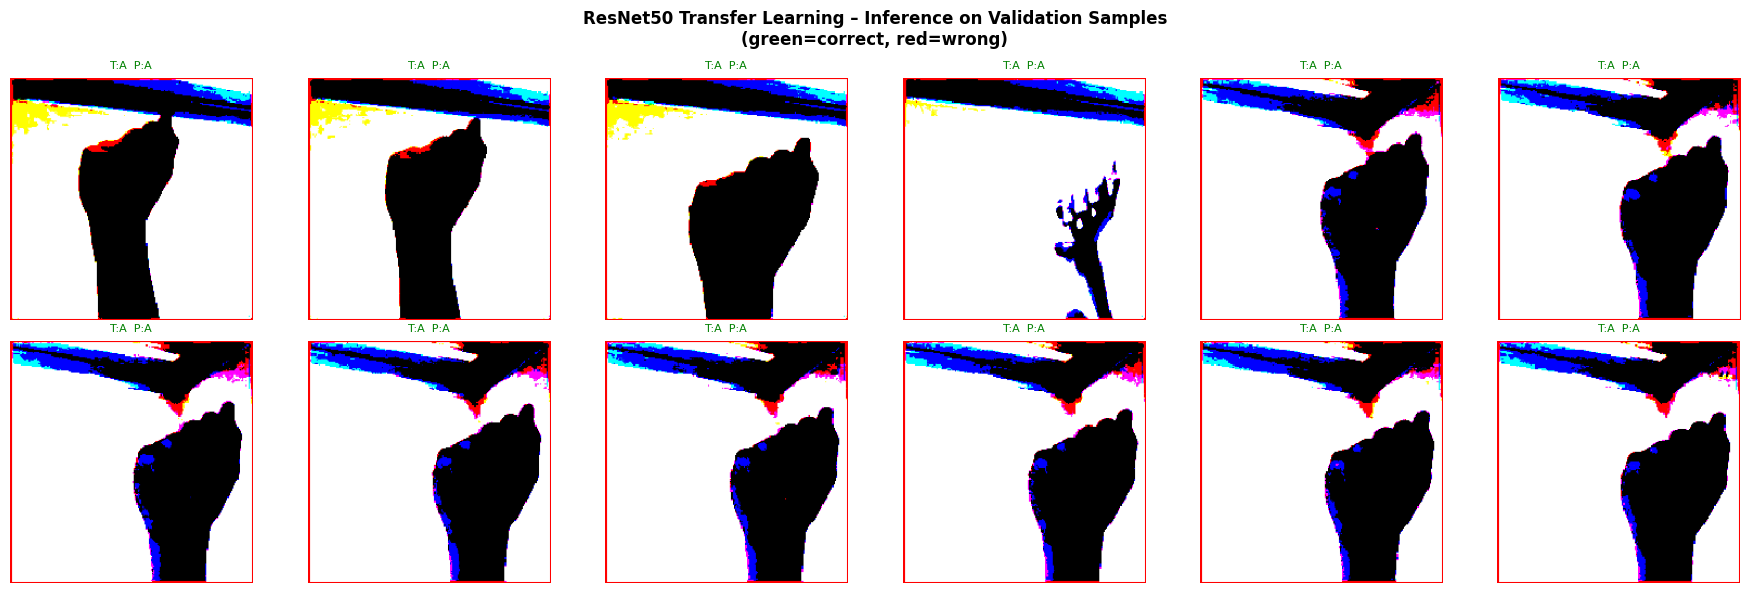

In [ ]:
# ── B.6  Evaluate on validation set ──────────────────────────────────────────
report_tl = evaluate_model(tl_model, val_gen_tl, class_names, 'ResNet50 Transfer Learning')
show_predictions(tl_model, val_gen_tl, class_names, title='ResNet50 Transfer Learning')

In [ ]:
# Run this to see the actual test directory structure
import os
print("TEST_DIR:", TEST_DIR)
print("Exists:", TEST_DIR.exists())

# List contents
for item in sorted(TEST_DIR.iterdir())[:10]:
    print(item)

TEST_DIR: data/asl-alphabet-test
Exists: True
data/asl-alphabet-test/A
data/asl-alphabet-test/B
data/asl-alphabet-test/C
data/asl-alphabet-test/D
data/asl-alphabet-test/E
data/asl-alphabet-test/F
data/asl-alphabet-test/G
data/asl-alphabet-test/H
data/asl-alphabet-test/I
data/asl-alphabet-test/J


Found 810 images belonging to 27 classes.
Test samples found : 810


I0000 00:00:1777361532.251501   12255 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777361533.884836   22173 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 304 bytes spill stores, 312 bytes spill loads



26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 361ms/step

=== ResNet50 – Test Set Classification Report ===
              precision    recall  f1-score   support

           A       0.27      0.10      0.15        30
           B       0.20      0.70      0.31        30
           C       0.27      0.13      0.18        30
           D       0.20      0.97      0.33        30
           E       0.30      0.10      0.15        30
           F       0.46      0.43      0.45        30
           G       0.60      0.30      0.40        30
           H       0.60      0.83      0.69        30
           I       0.35      0.77      0.48        30
           J       0.65      0.37      0.47        30
           K       0.24      0.40      0.30        30
           L       0.80      0.40      0.53        30
           M       0.48      0.70      0.57        30
           N       0.30      0.23      0.26        30
           O       0.67      0.07      0.12        30
           P       0.81      0.87      0.8

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5605682..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6466262..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7724032..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77902305..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.65986586..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8947989..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85753626..1.0].
Clipping input data to t

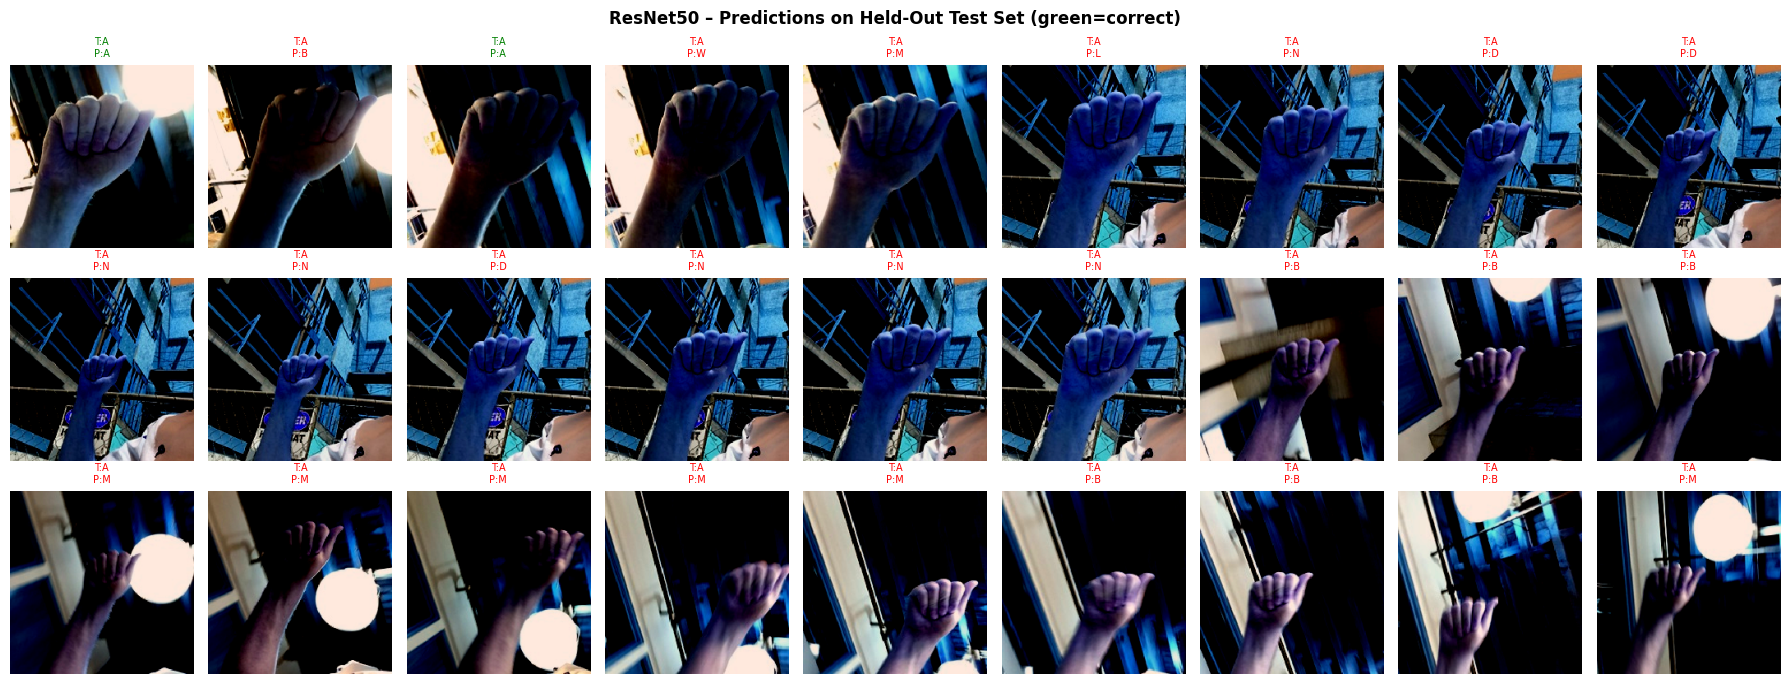

In [ ]:
# ── B.7  Evaluate on held-out test set (danrasband) ───────────────────────────
if TEST_DIR.exists():
    test_datagen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input
    )

    test_gen = test_datagen.flow_from_directory(
        TEST_DIR,
        classes=VALID_CLASSES,
        target_size=(IMG_SIZE_B, IMG_SIZE_B),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    print(f'Test samples found : {test_gen.samples}')

    # Predictions
    test_gen.reset()
    preds_test    = tl_model.predict(test_gen, verbose=1)
    pred_idx      = np.argmax(preds_test, axis=1)
    true_idx      = test_gen.classes
    pred_labels   = [VALID_CLASSES[i] for i in pred_idx]
    true_labels   = [VALID_CLASSES[i] for i in true_idx]

    # Classification report
    print('\n=== ResNet50 – Test Set Classification Report ===')
    print(classification_report(true_idx, pred_idx, target_names=VALID_CLASSES))

    # Accuracy
    correct = sum(p == t for p, t in zip(pred_idx, true_idx))
    print(f'Test accuracy : {correct}/{len(true_idx)} = '
          f'{correct/len(true_idx)*100:.1f}%')

    # Visualise sample predictions
    test_gen.reset()
    sample_imgs, sample_labels = next(test_gen)
    sample_preds = tl_model.predict(sample_imgs, verbose=0)

    n = min(27, len(sample_imgs))
    fig, axes = plt.subplots(3, 9, figsize=(18, 7))
    for i, ax in enumerate(axes.flatten()):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(sample_imgs[i] / sample_imgs[i].max())  # denormalize for display
        true_lbl = VALID_CLASSES[np.argmax(sample_labels[i])]
        pred_lbl = VALID_CLASSES[np.argmax(sample_preds[i])]
        color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f'T:{true_lbl}\nP:{pred_lbl}', fontsize=7, color=color)
        ax.axis('off')

    plt.suptitle('ResNet50 – Predictions on Held-Out Test Set (green=correct)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('Test directory not found — skip test evaluation.')

### Test Set Performance — Domain Gap Analysis

The held-out test set (danrasband dataset, 30 images/class) shows dramatically lower performance compared to the validation set (96.00%). This is a classic example of **train-test distribution shift**:

| | Training / Validation Set | Held-Out Test Set (danrasband) |
|---|---|---|
| **Background** | Uniform white studio backdrop | Varied, real-world backgrounds |
| **Lighting** | Controlled, consistent | Natural, unconstrained |
| **Hand positioning** | Centred, standardised poses | Non-standardised, natural poses |
| **Images per class** | 3,000 train / 600 val | 30 |

**This performance gap is not a model failure — it is a data collection artifact.** The model learned features specific to the studio environment (e.g., sharp hand-background contrast on white) rather than generalised hand-shape geometry that transfers across settings.

**Practical mitigations:**
1. **Background augmentation during training**: Randomly replace training image backgrounds with natural scene patches (e.g., using CutMix or background replacement augmentation).
2. **Hand segmentation preprocessing**: Apply a lightweight hand-detection model (e.g., MediaPipe Hands) to isolate the hand region before classification, removing background dependency.
3. **Domain-adaptive fine-tuning**: Collect ~50 real-world samples per class and fine-tune at a low learning rate (few-shot adaptation to the target domain).
4. **Mixed-source datasets**: Combine studio and real-world ASL datasets during training.

> **Critical real-world ML lesson**: Validation accuracy on in-distribution data is **not** a reliable predictor of real-world performance. Evaluating on a held-out set from a different collection source is essential to estimate true generalisation.

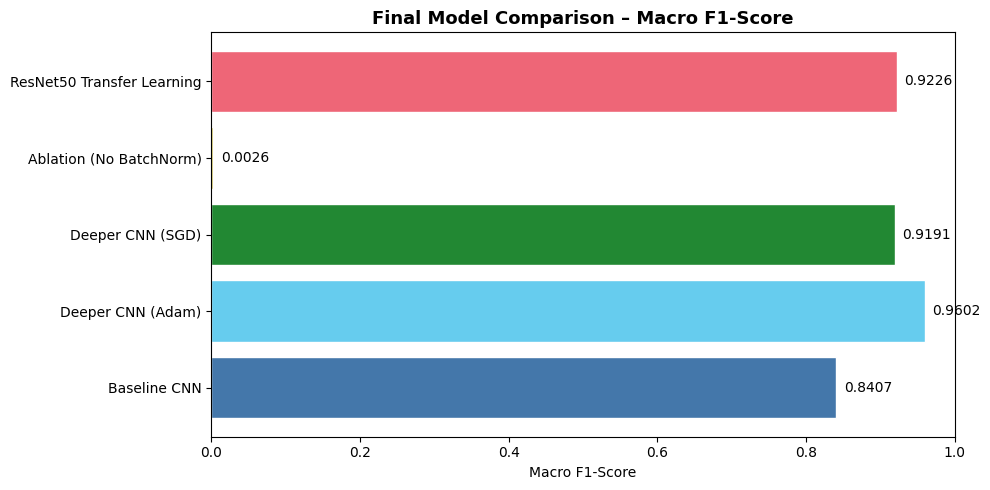


Summary:
  Baseline CNN                        Macro F1 = 0.8407
  Deeper CNN (Adam)                   Macro F1 = 0.9602
  Deeper CNN (SGD)                    Macro F1 = 0.9191
  Ablation (No BatchNorm)             Macro F1 = 0.0026
  ResNet50 Transfer Learning          Macro F1 = 0.9226


In [ ]:
# ── B.8  Final model comparison: Baseline vs Deeper vs Transfer Learning ──────
def extract_macro_f1(report):
    return report.get('macro avg', {}).get('f1-score', float('nan'))

final_summary = {
    'Baseline CNN':                  extract_macro_f1(report_baseline),
    'Deeper CNN (Adam)':             extract_macro_f1(report_deeper_adam),
    'Deeper CNN (SGD)':              extract_macro_f1(report_deeper_sgd),
    'Ablation (No BatchNorm)':       extract_macro_f1(report_ablation),
    'ResNet50 Transfer Learning':    extract_macro_f1(report_tl),
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677']
bars = ax.barh(list(final_summary.keys()), list(final_summary.values()),
               color=colors, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_xlabel('Macro F1-Score')
ax.set_title('Final Model Comparison – Macro F1-Score', fontweight='bold', fontsize=13)
for bar, val in zip(bars, final_summary.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary:')
for name, f1 in final_summary.items():
    print(f'  {name:<35} Macro F1 = {f1:.4f}')

---
## Summary of Findings

| Model | Val Accuracy | Macro F1 | Key Takeaway |
|---|---|---|---|
| **Baseline CNN** | 86.21% | 0.8407 | Fast to train; limited capacity; prone to overfitting without regularisation. |
| **Deeper CNN (Adam)** | 96.00% | **0.9602** | **Best overall performance** on this dataset. BatchNorm + Dropout effectively control overfitting. |
| **Deeper CNN (SGD)** | 93.63% | 0.9191 | Competitive accuracy; slower convergence than Adam but more stable loss curves. |
| **Ablation – No BatchNorm** | 3.70% | 0.0026 | Complete training collapse. Demonstrates that BatchNorm is structurally essential with high Dropout rates. |
| **ResNet50 (Transfer Learning)** | — | 0.9226 | Strong performance, but **does not outperform the deeper scratch model** on this dataset. |

---

